# CNN - VNINDEX

## Descriptions
1. Features: ["close"]
2. Timeshift: 20
3. Forecast horizon: 10

## Deploy TensorBoard

In [153]:
# tensorboard --logdir=src/model/lightning_logs/

## Import libraries

In [154]:
import os
import sys
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import FEATURE_SELECTION_LOG_FILE_BASE
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)

## Parameters

In [155]:
FORECAST_HORIZON = 10

In [156]:
COLUMN_ID = "stock"
TARGET_COLUMN = "close"
DATE_COLUMN = "date"

In [157]:
# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2025-12-31")

In [158]:
MAX_TIMESHIFT = 20
MIN_TIMESHIFT = 20

In [159]:
INPUT_SIZE = None
OUTPUT_SIZE = 1

## Hyper Parameters

In [160]:
MAX_EPOCHS = 100
LEARNING_RATE = 0.0001
PATIENCE = 10

## Start

### Get data

In [161]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [162]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [163]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [164]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [165]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [166]:
vn_index_df

,date,open,high,low,close,volume
0,2000-07-28,100.000000,100.000000,100.000000,100.000000,4200.0
1,2000-07-29,100.516667,100.516667,100.516667,100.516667,6233.0
2,2000-07-30,101.033333,101.033333,101.033333,101.033333,8267.0
3,2000-07-31,101.550000,101.550000,101.550000,101.550000,10300.0
4,2000-08-01,102.465000,102.465000,102.465000,102.465000,5300.0
...,...,...,...,...,...,...
9099,2025-06-26,1368.730000,1370.610000,1360.780000,1365.670000,598388700.0
9100,2025-06-27,1369.130000,1373.280000,1362.090000,1371.440000,677408300.0
9101,2025-06-28,1371.340000,1374.620000,1365.403333,1372.983333,663601667.0
9102,2025-06-29,1373.550000,1375.960000,1368.716667,1374.526667,649795033.0


In [167]:
vn_index_df_close = vn_index_df[["date", "close"]]
vn_index_df_close

,date,close
0,2000-07-28,100.000000
1,2000-07-29,100.516667
2,2000-07-30,101.033333
3,2000-07-31,101.550000
4,2000-08-01,102.465000
...,...,...
9099,2025-06-26,1365.670000
9100,2025-06-27,1371.440000
9101,2025-06-28,1372.983333
9102,2025-06-29,1374.526667


In [168]:
vn_index_df_close.loc[:, "stock"] = "vn_index"
vn_index_df_close

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20304\2662759176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vn_index_df_close.loc[:, "stock"] = "vn_index"


,date,close,stock
0,2000-07-28,100.000000,vn_index
1,2000-07-29,100.516667,vn_index
2,2000-07-30,101.033333,vn_index
3,2000-07-31,101.550000,vn_index
4,2000-08-01,102.465000,vn_index
...,...,...,...
9099,2025-06-26,1365.670000,vn_index
9100,2025-06-27,1371.440000,vn_index
9101,2025-06-28,1372.983333,vn_index
9102,2025-06-29,1374.526667,vn_index


### Roll time series

In [169]:
vn_index_df_close_rolled = roll_time_series(
    vn_index_df_close,
    column_id=COLUMN_ID,
    column_sort=DATE_COLUMN,
    max_timeshift=MAX_TIMESHIFT,
    min_timeshift=MIN_TIMESHIFT,
)
vn_index_df_close_rolled

Rolling: 100%|██████████| 50/50 [00:12<00:00,  4.15it/s]


,date,close,stock,id
0,2000-07-28,100.000000,vn_index,"(vn_index, 2000-08-17)"
1,2000-07-29,100.516667,vn_index,"(vn_index, 2000-08-17)"
2,2000-07-30,101.033333,vn_index,"(vn_index, 2000-08-17)"
3,2000-07-31,101.550000,vn_index,"(vn_index, 2000-08-17)"
4,2000-08-01,102.465000,vn_index,"(vn_index, 2000-08-17)"
...,...,...,...,...
186916,2025-06-26,1365.670000,vn_index,"(vn_index, 2025-06-30)"
186917,2025-06-27,1371.440000,vn_index,"(vn_index, 2025-06-30)"
186918,2025-06-28,1372.983333,vn_index,"(vn_index, 2025-06-30)"
186919,2025-06-29,1374.526667,vn_index,"(vn_index, 2025-06-30)"


### Extract features

In [170]:
X = extract_features(
    vn_index_df_close_rolled.drop(COLUMN_ID, axis=1),
    column_id="id",
    column_sort=DATE_COLUMN,
    column_value=TARGET_COLUMN,
    impute_function=impute,
    default_fc_parameters=ComprehensiveFCParameters(),
)

Feature Extraction: 100%|██████████| 50/50 [02:06<00:00,  2.52s/it]


In [171]:
X

close__variance_larger_than_standard_deviation  \
vn_index 2000-08-17                                             1.0   
         2000-08-18                                             1.0   
         2000-08-19                                             1.0   
         2000-08-20                                             1.0   
         2000-08-21                                             1.0   
...                                                             ...   
         2025-06-26                                             1.0   
         2025-06-27                                             1.0   
         2025-06-28                                             1.0   
         2025-06-29                                             1.0   
         2025-06-30                                             1.0   

                     close__has_duplicate_max  close__has_duplicate_min  \
vn_index 2000-08-17                       0.0                       0.0   
         2000-08-18                       0.0                       0.0   
         2000-08-19                       0.0                       0.0   
         2000-08-20                       0.0                       0.0   
         2000-08-21                       0.0                       0.0   
...                                       ...                       ...   
         2025-06-26                       0.0                       0.0   
         2025-06-27                       0.0                       0.0   
         2025-06-28                       0.0                       0.0   
         2025-06-29                       0.0                       0.0   
         2025-06-30                       0.0                       0.0   

                     close__has_duplicate  close__sum_values  \
vn_index 2000-08-17                   0.0        2249.675000   
         2000-08-18                   0.0        2265.195000   
         2000-08-19                   0.0        2280.771667   
         2000-08-20                   0.0        2296.405000   
         2000-08-21                   0.0        2312.095000   
...                                   ...                ...   
         2025-06-26                   0.0       28103.350000   
         2025-06-27                   0.0       28144.900000   
         2025-06-28                   0.0       28194.433333   
         2025-06-29                   0.0       28251.950000   
         2025-06-30                   0.0       28317.450000   

                     close__abs_energy  close__mean_abs_change  \
vn_index 2000-08-17       2.414266e+05                0.733000   
         2000-08-18       2.447715e+05                0.750167   
         2000-08-19       2.481455e+05                0.753000   
         2000-08-20       2.515489e+05                0.755833   
         2000-08-21       2.549817e+05                0.738750   
...                                ...                     ...   
         2025-06-26       3.761674e+07                5.039000   
         2025-06-27       3.772898e+07                5.005500   
         2025-06-28       3.786255e+07                4.760667   
         2025-06-29       3.801735e+07                4.515833   
         2025-06-30       3.819333e+07                4.310000   

                     close__mean_change  \
vn_index 2000-08-17            0.733000   
         2000-08-18            0.750167   
         2000-08-19            0.753000   
         2000-08-20            0.755833   
         2000-08-21            0.738750   
...                                 ...   
         2025-06-26            1.789000   
         2025-06-27            2.399500   
         2025-06-28            2.798667   
         2025-06-29            3.197833   
         2025-06-30            2.992000   

                     close__mean_second_derivative_central  close__median  \
vn_index 2000-08-17                               0.009035         106.92   
         2000-08-18               

In [172]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2000-08-17,1.0,0.0,0.0,0.0,2249.675000,2.414266e+05,0.733000,0.733000,0.009035,106.92,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,112.325714
2000-08-18,1.0,0.0,0.0,0.0,2265.195000,2.447715e+05,0.750167,0.750167,0.009035,107.78,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,113.062857
2000-08-19,1.0,0.0,0.0,0.0,2280.771667,2.481455e+05,0.753000,0.753000,0.001491,108.64,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,113.800000
2000-08-20,1.0,0.0,0.0,0.0,2296.405000,2.515489e+05,0.755833,0.755833,-0.008991,109.50,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,114.537143
2000-08-21,1.0,0.0,0.0,0.0,2312.095000,2.549817e+05,0.738750,0.738750,-0.008991,110.36,...,0.304636,0.304636,1.159589,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,115.274286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,1.0,0.0,0.0,0.0,28103.350000,3.761674e+07,5.039000,1.789000,0.141053,1338.11,...,0.304636,0.600166,1.294545,1.489767,2.120208,2.507026,2.512659,2.523211,0.0,1359.562857
2025-06-27,1.0,0.0,0.0,0.0,28144.900000,3.772898e+07,5.005500,2.399500,0.321316,1346.83,...,0.304636,0.600166,1.159589,1.458585,2.120208,2.507026,2.512659,2.523211,0.0,1362.334286
2025-06-28,1.0,0.0,0.0,0.0,28194.433333,3.786255e+07,4.760667,2.798667,0.210088,1347.69,...,0.304636,0.304636,1.294545,1.380452,2.014123,2.507026,2.512659,2.523211,0.0,1365.290000


### Create forecast target

In [173]:
y = (
    vn_index_df_close.set_index(DATE_COLUMN)
    .sort_index()[TARGET_COLUMN]
    .shift(-FORECAST_HORIZON)
    .dropna()
)
y = pd.DataFrame(y)
y

,close
date,
2000-07-28,106.920000
2000-07-29,107.780000
2000-07-30,108.640000
2000-07-31,109.500000
2000-08-01,110.360000
...,...
2025-06-16,1365.670000
2025-06-17,1371.440000
2025-06-18,1372.983333


In [174]:
y = y[y.index.isin(X.index)]
X = X[X.index.isin(y.index)]

In [175]:
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2000-08-17,1.0,0.0,0.0,0.0,2249.675000,2.414266e+05,0.733000,0.733000,0.009035,106.920000,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000,0.0,112.325714
2000-08-18,1.0,0.0,0.0,0.0,2265.195000,2.447715e+05,0.750167,0.750167,0.009035,107.780000,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000,0.0,113.062857
2000-08-19,1.0,0.0,0.0,0.0,2280.771667,2.481455e+05,0.753000,0.753000,0.001491,108.640000,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000,0.0,113.800000
2000-08-20,1.0,0.0,0.0,0.0,2296.405000,2.515489e+05,0.755833,0.755833,-0.008991,109.500000,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000,0.0,114.537143
2000-08-21,1.0,0.0,0.0,0.0,2312.095000,2.549817e+05,0.738750,0.738750,-0.008991,110.360000,...,0.304636,0.304636,1.159589,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000,0.0,115.274286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-16,1.0,0.0,0.0,0.0,27938.960000,3.717326e+07,5.363000,-0.085000,0.144211,1332.600000,...,0.600166,0.885574,1.540306,1.517307,2.245172,2.639341,2.685945,2.70805,0.0,1342.390000
2025-06-17,1.0,0.0,0.0,0.0,27946.840000,3.719444e+07,5.739000,0.291000,0.252368,1332.600000,...,0.600166,1.033562,1.414279,1.493411,2.120208,2.557794,2.685945,2.70805,0.0,1343.515714
2025-06-18,1.0,0.0,0.0,0.0,27951.800000,3.720778e+07,5.781500,0.248500,0.221053,1332.600000,...,0.885574,0.885574,1.767761,1.517307,2.120208,2.476247,2.599302,2.70805,0.0,1344.224286


In [176]:
y

,close
date,
2000-08-17,117.613333
2000-08-18,117.000000
2000-08-19,116.075000
2000-08-20,115.150000
2000-08-21,114.260000
...,...
2025-06-16,1365.670000
2025-06-17,1371.440000
2025-06-18,1372.983333


### Create train set

In [177]:
TRAIN_RANGE[0], TRAIN_RANGE[1]

('2000-01-01', '2021-12-31')

In [178]:
X_train = X.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
X_train

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2000-08-17,1.0,0.0,0.0,0.0,2249.675000,2.414266e+05,0.733000,0.733000,0.009035,106.92,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000,0.0,112.325714
2000-08-18,1.0,0.0,0.0,0.0,2265.195000,2.447715e+05,0.750167,0.750167,0.009035,107.78,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000,0.0,113.062857
2000-08-19,1.0,0.0,0.0,0.0,2280.771667,2.481455e+05,0.753000,0.753000,0.001491,108.64,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000,0.0,113.800000
2000-08-20,1.0,0.0,0.0,0.0,2296.405000,2.515489e+05,0.755833,0.755833,-0.008991,109.50,...,0.304636,0.304636,0.885574,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000,0.0,114.537143
2000-08-21,1.0,0.0,0.0,0.0,2312.095000,2.549817e+05,0.738750,0.738750,-0.008991,110.36,...,0.304636,0.304636,1.159589,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000,0.0,115.274286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,1.0,0.0,0.0,0.0,30934.680000,4.557145e+07,5.044500,2.105500,-0.056579,1476.61,...,1.033562,1.540306,2.397895,1.497896,2.370135,2.670120,2.772589,2.70805,0.0,1481.491429
2021-12-28,1.0,0.0,0.0,0.0,30982.300000,4.571150e+07,5.015000,2.076000,-0.252632,1477.03,...,1.366711,1.767761,2.397895,1.497896,2.351257,2.588573,2.772589,2.70805,0.0,1483.811429
2021-12-29,1.0,0.0,0.0,0.0,31015.250000,4.580833e+07,4.688000,0.892000,-0.108684,1477.33,...,1.414279,1.641735,2.098274,1.616282,2.351257,2.588573,2.772589,2.70805,0.0,1484.822857


In [179]:
y_train = y.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
y_train

,close
date,
2000-08-17,117.613333
2000-08-18,117.000000
2000-08-19,116.075000
2000-08-20,115.150000
2000-08-21,114.260000
...,...
2021-12-27,1528.570000
2021-12-28,1528.480000
2021-12-29,1520.223333


### Select features

In [180]:
X_train_selected = select_features(X_train, y_train[TARGET_COLUMN])
X_train_selected

,close__sum_values,close__absolute_sum_of_changes,close__root_mean_square,close__variance,close__standard_deviation,close__mean,close__median,close__mean_abs_change,"close__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""var""",close__abs_energy,...,close__variation_coefficient,"close__cwt_coefficients__coeff_9__w_2__widths_(2, 5, 10, 20)",close__fourier_entropy__bins_5,close__fourier_entropy__bins_3,"close__agg_autocorrelation__f_agg_""median""__maxlag_40",close__ratio_beyond_r_sigma__r_0.5,"close__cwt_coefficients__coeff_11__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_10__w_2__widths_(2, 5, 10, 20)","close__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""max""",close__autocorrelation__lag_9
last_date,,,,,,,,,,,,,,,,,,,,,
2000-08-17,2249.675000,14.660000,107.221756,20.229215,4.497690,107.127381,106.92,0.733000,1.255139,2.414266e+05,...,0.041985,0.111580,0.304636,0.304636,-0.505227,0.714286,-0.366023,-0.260801,4.156667,-0.229064
2000-08-18,2265.195000,15.003333,107.961959,20.618095,4.540715,107.866429,107.78,0.750167,1.193336,2.447715e+05,...,0.042096,-0.241258,0.304636,0.304636,-0.506327,0.714286,-0.162580,-0.366347,4.300000,-0.221641
2000-08-19,2280.771667,15.060000,108.703515,20.718525,4.551761,108.608175,108.64,0.753000,1.215971,2.481455e+05,...,0.041910,-0.346704,0.304636,0.304636,-0.505850,0.714286,0.180201,-0.162906,4.156667,-0.221330
2000-08-20,2296.405000,15.116667,109.446424,20.524378,4.530384,109.352619,109.50,0.755833,1.223657,2.515489e+05,...,0.041429,-0.143161,0.304636,0.304636,-0.504080,0.714286,0.398207,0.179874,4.013333,-0.219915
2000-08-21,2312.095000,14.775000,110.190685,20.029485,4.475431,110.099762,110.36,0.738750,1.260908,2.549817e+05,...,0.040649,0.199720,0.304636,0.304636,-0.501196,0.714286,0.321677,0.397879,3.870000,-0.226016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,30934.680000,100.890000,1473.115371,104.210411,10.208350,1473.080000,1476.61,5.044500,0.531717,4.557145e+07,...,0.006930,4.021763,1.033562,0.759547,-0.049676,0.523810,5.476924,4.131697,6.135000,-0.126890
2021-12-28,30982.300000,100.300000,1475.377351,87.730219,9.366441,1475.347619,1477.03,5.015000,18.936114,4.571150e+07,...,0.006349,4.414730,1.366711,0.859967,-0.004533,0.428571,6.639488,5.475928,7.300000,-0.041900
2021-12-29,31015.250000,93.760000,1476.939156,66.431519,8.150553,1476.916667,1477.33,4.688000,42.443335,4.580833e+07,...,0.005519,5.760181,1.414279,0.994924,0.017619,0.428571,6.223545,6.638799,3.015000,0.051626


In [181]:
INPUT_SIZE = X_train_selected.shape[1]
INPUT_SIZE

312

### Create validation set

In [182]:
VALIDATION_RANGE[0], VALIDATION_RANGE[1]

('2022-01-01', '2023-12-31')

In [183]:
X_validation_selected = X.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]][
    X_train_selected.columns
]
X_validation_selected

,close__sum_values,close__absolute_sum_of_changes,close__root_mean_square,close__variance,close__standard_deviation,close__mean,close__median,close__mean_abs_change,"close__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""var""",close__abs_energy,...,close__variation_coefficient,"close__cwt_coefficients__coeff_9__w_2__widths_(2, 5, 10, 20)",close__fourier_entropy__bins_5,close__fourier_entropy__bins_3,"close__agg_autocorrelation__f_agg_""median""__maxlag_40",close__ratio_beyond_r_sigma__r_0.5,"close__cwt_coefficients__coeff_11__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_10__w_2__widths_(2, 5, 10, 20)","close__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""max""",close__autocorrelation__lag_9
last_date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,31105.321667,100.158333,1481.237927,95.194635,9.756774,1481.205794,1478.740000,5.007917,65.922666,4.607538e+07,...,0.006587,1.929978,1.033562,0.759547,-0.305467,0.428571,-18.113164,-8.172057,12.65750,-0.473750
2022-01-02,31145.265000,102.760000,1483.152520,132.480816,11.510031,1483.107857,1478.970000,5.138000,88.642803,4.619457e+07,...,0.007761,-7.884076,0.885574,0.600166,-0.403623,0.571429,-19.756803,-18.114000,16.07000,-0.417663
2022-01-03,31187.810000,109.395000,1485.196638,186.621016,13.660930,1485.133810,1479.790000,5.469750,51.317218,4.632199e+07,...,0.009198,-17.825196,0.759547,0.600166,-0.496365,0.619048,-10.945980,-19.757693,19.48250,-0.332533
2022-01-04,31237.370000,115.700000,1487.579520,254.995835,15.968589,1487.493810,1480.980000,5.785000,72.823999,4.647075e+07,...,0.010735,-19.468939,0.600166,0.304636,-0.566589,0.666667,1.351916,-10.947016,22.89500,-0.336745
2022-01-05,31284.370000,117.670000,1489.833091,301.490665,17.363487,1489.731905,1484.930000,5.883500,100.660857,4.661166e+07,...,0.011655,-10.658360,0.600166,0.304636,-0.623765,0.714286,8.080746,1.350933,20.76000,-0.313792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,23346.860000,72.520000,1111.814408,131.569142,11.470359,1111.755238,1112.793333,3.626000,23.250665,2.595876e+07,...,0.010317,-14.222252,0.759547,0.759547,0.126365,0.809524,-20.002139,-19.221444,-2.82000,-0.998157
2023-12-28,23354.300000,76.510000,1112.172905,140.977284,11.873386,1112.109524,1112.793333,3.825500,18.675034,2.597550e+07,...,0.010676,-19.001995,0.885574,0.600166,0.114238,0.761905,-16.728193,-20.002294,0.65000,-1.003888
2023-12-29,23359.790000,77.156667,1112.437831,148.791259,12.198002,1112.370952,1112.793333,3.857833,12.818803,2.598788e+07,...,0.010966,-19.782265,0.885574,0.600166,0.052392,0.761905,-11.476449,-16.728308,1.15000,-0.942133


In [184]:
y_validation = y.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]]
y_validation

,close
date,
2022-01-01,1492.310000
2022-01-02,1510.510000
2022-01-03,1496.050000
2022-01-04,1496.020000
2022-01-05,1481.626667
...,...
2023-12-27,1156.516667
2023-12-28,1158.353333
2023-12-29,1160.190000


### Create test set

In [185]:
TEST_RANGE[0], TEST_RANGE[1]

('2024-01-01', '2025-12-31')

In [186]:
X_test_selected = X.loc[TEST_RANGE[0] : TEST_RANGE[1]][X_train_selected.columns]
X_test_selected

,close__sum_values,close__absolute_sum_of_changes,close__root_mean_square,close__variance,close__standard_deviation,close__mean,close__median,close__mean_abs_change,"close__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""var""",close__abs_energy,...,close__variation_coefficient,"close__cwt_coefficients__coeff_9__w_2__widths_(2, 5, 10, 20)",close__fourier_entropy__bins_5,close__fourier_entropy__bins_3,"close__agg_autocorrelation__f_agg_""median""__maxlag_40",close__ratio_beyond_r_sigma__r_0.5,"close__cwt_coefficients__coeff_11__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_10__w_2__widths_(2, 5, 10, 20)","close__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""max""",close__autocorrelation__lag_9
last_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,23376.825,75.662500,1113.260058,173.473697,13.170941,1113.182143,1112.793333,3.783125,22.361403,2.602631e+07,...,0.011832,-7.278382,0.304636,0.304636,-0.191297,0.761905,-4.804178,-5.897500,1.821250,-0.716439
2024-01-02,23380.915,62.680000,1113.457674,179.860125,13.411194,1113.376905,1112.793333,3.134000,24.526860,2.603555e+07,...,0.012046,-5.676844,0.304636,0.304636,-0.421589,0.761905,-2.333476,-4.804264,8.760000,-0.621100
2024-01-03,23410.885,71.060000,1114.904036,222.944209,14.931316,1114.804048,1112.793333,3.553000,15.012784,2.610323e+07,...,0.013394,-4.586280,0.304636,0.304636,-0.649235,0.714286,1.101303,-2.334103,17.020000,-0.454517
2024-01-04,23451.475,69.780000,1116.862081,279.594411,16.721077,1116.736905,1117.660000,3.489000,17.531755,2.619500e+07,...,0.014973,-2.116934,0.304636,0.304636,-0.631514,0.809524,3.967352,1.100454,18.963333,-0.307096
2024-01-05,23503.855,70.266667,1119.379499,332.004105,18.220980,1119.231190,1121.990000,3.513333,24.230132,2.631322e+07,...,0.016280,1.316072,0.304636,0.304636,-0.502735,0.809524,5.732087,3.966256,18.510000,-0.244252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-16,27938.960,107.260000,1330.471844,120.212096,10.964128,1330.426667,1332.600000,5.363000,16.157358,3.717326e+07,...,0.008241,25.156411,0.600166,0.474139,-0.311240,0.761905,-1.930778,14.133350,-4.570000,-0.500757
2025-06-17,27946.840,114.780000,1330.850773,130.070137,11.404830,1330.801905,1332.600000,5.739000,26.174612,3.719444e+07,...,0.008570,14.395520,0.600166,0.474139,-0.083843,0.714286,-15.752195,-1.930942,0.220000,-0.677094
2025-06-18,27951.800,115.630000,1331.089338,136.414213,11.679650,1331.038095,1332.600000,5.781500,57.431065,3.720778e+07,...,0.008775,-1.668364,0.885574,0.600166,0.166943,0.714286,-22.352513,-15.752298,-0.210000,-0.831873


In [187]:
y_test = y.loc[TEST_RANGE[0] : TEST_RANGE[1]]
y_test

,close
date,
2024-01-01,1162.220000
2024-01-02,1154.700000
2024-01-03,1154.506667
2024-01-04,1154.313333
2024-01-05,1154.120000
...,...
2025-06-16,1365.670000
2025-06-17,1371.440000
2025-06-18,1372.983333


### Create scaler

In [188]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaler = X_scaler.fit_transform(X_train_selected)
y_train_scaler = y_scaler.fit_transform(y_train)

X_validation_scaler = X_scaler.transform(X_validation_selected)
y_validation_scaler = y_scaler.transform(y_validation)

X_test_scaler = X_scaler.transform(X_test_selected)
y_test_scaler = y_scaler.transform(y_test)

In [189]:
X_train_scaler.shape

(7807, 312)

In [190]:
y_train_scaler.shape

(7807, 1)

In [191]:
X_validation_scaler.shape

(730, 312)

In [192]:
y_validation_scaler.shape

(730, 1)

In [193]:
X_test_scaler.shape

(537, 312)

In [194]:
y_test_scaler.shape

(537, 1)

### Create dataloader

In [195]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaler, dtype=torch.float32),
    torch.tensor(y_train_scaler, dtype=torch.float32),
)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [196]:
validation_dataset = TensorDataset(
    torch.tensor(X_validation_scaler, dtype=torch.float32),
    torch.tensor(y_validation_scaler, dtype=torch.float32),
)
validation_dataloader = DataLoader(validation_dataset, batch_size=32)

In [197]:
test_dataset = TensorDataset(
    torch.tensor(X_test_scaler, dtype=torch.float32),
    torch.tensor(y_test_scaler, dtype=torch.float32),
)
test_dataloader = DataLoader(test_dataset, batch_size=32)

### Create model

In [198]:
class LightningCNN(L.LightningModule):

    def __init__(self):
        super().__init__()

        L.seed_everything(seed=18)

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        # 315 → /2 → /2 ≈ 78 (floor)
        self.fc = nn.Sequential(nn.Linear(64 * 78, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, x):
        # x: [batch, 315]
        x = x.unsqueeze(1)  # → [batch, 1, 315]

        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=LEARNING_RATE)

    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("val_loss", loss, prog_bar=True)
        return loss

In [199]:
model = LightningCNN()

Seed set to 18


### Train model

In [200]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [201]:
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS, log_every_n_steps=1, callbacks=[early_stop_callback]
)

trainer.fit(
    model, train_dataloaders=train_dataloader, val_dataloaders=validation_dataloader
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv │ Sequential │  6.3 K │ train │     0 │
│ 1 │ fc   │ Sequential │  319 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 325 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 325 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

In [202]:
y_test

,close
date,
2024-01-01,1162.220000
2024-01-02,1154.700000
2024-01-03,1154.506667
2024-01-04,1154.313333
2024-01-05,1154.120000
...,...
2025-06-16,1365.670000
2025-06-17,1371.440000
2025-06-18,1372.983333


In [203]:
y_test.shape

(537, 1)

In [204]:
y_pred_tensor = model(torch.tensor(X_test_scaler, dtype=torch.float32))

y_pred_numpy = y_pred_tensor.detach().cpu().numpy()

# Ensure correct shape for the scaler
y_pred_numpy = y_pred_numpy.reshape(-1, 1)

# Inverse transform
y_pred_inverse = y_scaler.inverse_transform(y_pred_numpy)

# Create Pandas Dataframe
y_predict = pd.DataFrame(y_pred_inverse.squeeze(), index=X_test_selected.index)

y_predict

,0
last_date,
2024-01-01,1137.554565
2024-01-02,1134.794556
2024-01-03,1155.562256
2024-01-04,1163.999756
2024-01-05,1164.068604
...,...
2025-06-16,1368.665283
2025-06-17,1388.914307
2025-06-18,1375.172485


<Axes: xlabel='last_date'>

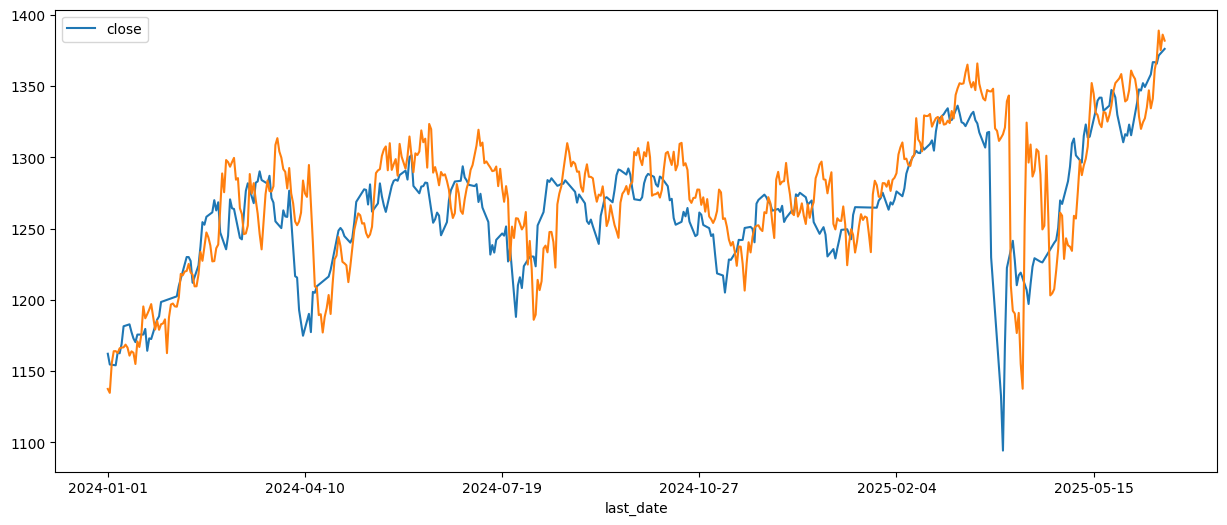

In [205]:
plt.figure(figsize=(15, 6))

y_test.plot(ax=plt.gca())
y_predict.plot(ax=plt.gca(), legend=None, marker=None)

In [206]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# Convert to numpy arrays (flatten in case they are DataFrames)
y_true = y_test.values.flatten()
y_pred = y_predict.values.flatten()

In [207]:
# 1️⃣ MSE (Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)

# 2️⃣ MAPE (Mean Absolute Percentage Error)
# Avoid division by zero
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 3️⃣ RMSSE (Root Mean Squared Scaled Error)
# RMSSE needs scaling by naive forecast (lag-1)
# denominator = mean squared difference of actuals
denominator = np.mean(np.diff(y_true) ** 2)
rmsse = np.sqrt(mse / denominator)

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f} %")
print(f"RMSSE: {rmsse:.4f}")

MSE: 1306.6802
MAPE: 2.0805 %
RMSSE: 3.8737
